# Label-source ablation — test results

Compares synthetic_intent distillation runs (gpt-oss-120b → gemma-3-12b, lr=2e-5) under several training-data variants. The first three conditions form the label-source ablation; the last three are appendix-only comparators added for context.

**Label-source ablation:**

- **hard_human** — main-sweep adapter, hard subset (n≈1378) with 5-level human labels.
- **hard_original** — same hard subset, but with the original WildGuardMix binary labels.
- **random_original** — random size-matched WG sample (n≈1378), original binary labels. Run with **three seeds (42, 43, 44)** to estimate variance from data-selection randomness; the main table reports mean ± std across seeds, and per-seed values are shown in the appendix table below. *Trace-sourcing note:* seed=42 traces come from a dedicated gpt-oss-120b teacher pass; seed=43 and seed=44 traces are filtered out of the full-WG scaling pool (same teacher, same `synthetic_intent` condition, same generation config). Teacher-pass stochasticity may add a small constant bias between seed=42 and the other two, but does not affect the data-selection variance we're measuring.

**Appendix comparators (broader data sources):**

- **broader_intent_mix** — annotated `human_intent` (n=1378) + harm-stratified random WG `synthetic_intent` (n=1378). Human intents on the annotated half, model-generated intents on the broader half. See `submit_broader_intent_mix.py`.
- **broader_intent_mix_synthetic** — same prompt mix but `synthetic_intent` on both halves (n=1378+1378). Only the annotated half's intent source differs from `broader_intent_mix`.
- **wildguardmix_full** — full WildGuardMix train split (~86.7k examples, 1 epoch). See `submit_scaling.py`.

The `hard_human` vs `hard_original` delta isolates the relabeling effect; `hard_original` vs `random_original` isolates the hard-subset effect. The last three place the small-data ablation conditions on the same scale as broader data sources, and the two `broader_intent_mix` variants isolate the effect of human vs synthetic intents on the annotated half.

Each row of the main table is a held-out evaluation dataset; columns are the conditions plus their pairwise deltas vs `hard_human`.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path("../../").resolve()

# Test eval output roots — see configs/experiments/ablations/label_source_ablation.yaml
# and configs/experiments/scaling/data_scaling.yaml.
ABLATION_TEST_ROOT = PROJECT_ROOT / "data" / "safety_experiment" / "distillation-ablations"
SCALING_TEST_ROOT  = PROJECT_ROOT / "data" / "safety_experiment" / "distillation-scaling"
BASELINE_TEST_DIR  = PROJECT_ROOT / "data" / "safety_experiment" / "distillation" / "openai-gpt-oss-120b" / "gemma-3-12b" / "synthetic_intent"

# Dataset slug → display name. Order is also the row order in the table.
DATASETS = {
    "annotated-intents": "Annotated Intents",
    "wildguardmix":      "WildGuardMix",
    "xstest":            "XSTest",
    "toxic-chat":        "Toxic Chat",
    "aegis":             "Aegis",
    "openai-moderation": "OpenAI Moderation",
}

# Condition slug → (display name, test results dir). Three random_original
# seeds load independently and are collapsed into a single group (see
# CONDITION_GROUPS below) for the main table.
CONDITIONS = {
    "hard_human":             ("Hard subset · human labels (baseline)", BASELINE_TEST_DIR),
    "hard_original":          ("Hard subset · WG labels",                ABLATION_TEST_ROOT / "hard_original"),
    "random_original":        ("Random WG · WG labels (seed=42)",        ABLATION_TEST_ROOT / "random_original"),
    "random_original_seed43": ("Random WG · WG labels (seed=43)",        ABLATION_TEST_ROOT / "random_original_seed43"),
    "random_original_seed44": ("Random WG · WG labels (seed=44)",        ABLATION_TEST_ROOT / "random_original_seed44"),
    "broader_intent_mix": (
        "Annotated (human int.) + Random WG (synth int.)",
        ABLATION_TEST_ROOT / "broader_intent_mix",
    ),
    "broader_intent_mix_synthetic": (
        "Annotated (synth int.) + Random WG (synth int.)",
        ABLATION_TEST_ROOT / "broader_intent_mix_synthetic",
    ),
    "wildguardmix_full": (
        "Full WildGuardMix · synth intents",
        SCALING_TEST_ROOT / "full_wg",
    ),
}

# Condition slug → group slug. Multi-seed groups are aggregated to mean ± std
# in the main table; single-condition groups map to themselves.
CONDITION_GROUPS = {
    "hard_human":                   "hard_human",
    "hard_original":                "hard_original",
    "random_original":              "random_original",
    "random_original_seed43":       "random_original",
    "random_original_seed44":       "random_original",
    "broader_intent_mix":           "broader_intent_mix",
    "broader_intent_mix_synthetic": "broader_intent_mix_synthetic",
    "wildguardmix_full":            "wildguardmix_full",
}

GROUP_LABELS = {
    "hard_human":                   "Hard subset · human labels (baseline)",
    "hard_original":                "Hard subset · WG labels",
    "random_original":              "Random WG · WG labels (mean of 3 seeds)",
    "broader_intent_mix":           "Annotated (human int.) + Random WG (synth int.)",
    "broader_intent_mix_synthetic": "Annotated (synth int.) + Random WG (synth int.)",
    "wildguardmix_full":            "Full WildGuardMix · synth intents",
}
GROUP_ORDER = [
    "hard_human",
    "hard_original",
    "random_original",
    "broader_intent_mix",
    "broader_intent_mix_synthetic",
    "wildguardmix_full",
]

# Held-out average excludes annotated-intents (its val split was used for adapter selection).
HELD_OUT_DATASETS = [d for d in DATASETS if d != "annotated-intents"]


In [2]:
def load_jsonl(path: Path) -> list[dict]:
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def harm_f1(records: list[dict]) -> tuple[float, int]:
    """Binary harm F1 (positive = harmful). Returns (f1, n_records).

    Mirrors the convention in submit_distillation_eval.compute_ood_val_f1:
    parse failures (missing predicted_harm) are treated as 'safe', so models
    that ramble past max_new_tokens without producing a label are penalised.
    """
    tp = fp = tn = fn = 0
    for r in records:
        true_harm = (r.get("true_harm_binary") or r.get("true_harm") or "").lower()
        if not true_harm:
            continue
        pred_harm = (r.get("predicted_harm") or "safe").lower()
        if true_harm == "harmful" and pred_harm == "harmful":
            tp += 1
        elif true_harm == "safe" and pred_harm == "harmful":
            fp += 1
        elif true_harm == "safe" and pred_harm == "safe":
            tn += 1
        elif true_harm == "harmful" and pred_harm == "safe":
            fn += 1
    n = tp + fp + tn + fn
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    return f1, n


def find_jsonl(dataset_dir: Path) -> Path | None:
    """Each test eval drops one *.jsonl file per dataset directory."""
    if not dataset_dir.exists():
        return None
    candidates = list(dataset_dir.glob("*.jsonl"))
    if not candidates:
        return None
    return candidates[0]


def load_condition_f1(condition_dir: Path) -> dict[str, tuple[float, int]]:
    """{dataset_slug -> (f1, n)} for one condition."""
    out = {}
    for ds_slug in DATASETS:
        jpath = find_jsonl(condition_dir / ds_slug)
        if jpath is None:
            continue
        out[ds_slug] = harm_f1(load_jsonl(jpath))
    return out

In [3]:
# Load every condition independently. Conditions whose test eval has not run
# yet stay in the index with NaN values, so a partial run is still readable.
rows = []
for cond_slug, (cond_label, cond_dir) in CONDITIONS.items():
    per_ds = load_condition_f1(cond_dir)
    if not per_ds:
        print(f"[warn] no test results found for '{cond_slug}' under {cond_dir}")
    for ds_slug, ds_label in DATASETS.items():
        f1, n = per_ds.get(ds_slug, (np.nan, 0))
        rows.append({
            "condition_slug": cond_slug,
            "condition":      cond_label,
            "group_slug":     CONDITION_GROUPS[cond_slug],
            "group":          GROUP_LABELS[CONDITION_GROUPS[cond_slug]],
            "dataset_slug":   ds_slug,
            "dataset":        ds_label,
            "f1":             f1,
            "n":              n,
        })

long_df = pd.DataFrame(rows)
long_df.head(len(DATASETS) * len(CONDITIONS))


,condition_slug,condition,group_slug,group,dataset_slug,dataset,f1,n
0,hard_human,Hard subset · human labels (baseline),hard_human,Hard subset · human labels (baseline),annotated-intents,Annotated Intents,0.745562,173
1,hard_human,Hard subset · human labels (baseline),hard_human,Hard subset · human labels (baseline),wildguardmix,WildGuardMix,0.878517,1699
2,hard_human,Hard subset · human labels (baseline),hard_human,Hard subset · human labels (baseline),xstest,XSTest,0.910345,450
3,hard_human,Hard subset · human labels (baseline),hard_human,Hard subset · human labels (baseline),toxic-chat,Toxic Chat,0.683603,5083
4,hard_human,Hard subset · human labels (baseline),hard_human,Hard subset · human labels (baseline),aegis,Aegis,0.813388,1964
5,hard_human,Hard subset · human labels (baseline),hard_human,Hard subset · human labels (baseline),openai-moderation,OpenAI Moderation,0.769359,1680
6,hard_original,Hard subset · WG labels,hard_original,Hard subset · WG labels,annotated-intents,Annotated Intents,0.750000,173
7,hard_original,Hard subset · WG labels,hard_original,Hard subset · WG labels,wildguardmix,WildGuardMix,0.872681,1699
8,hard_original,Hard subset · WG labels,hard_original,Hard subset · WG labels,xstest,XSTest,0.892857,450
9,hard_original,Hard subset · WG labels,hard_original,Hard subset · WG labels,toxic-chat,Toxic Chat,0.677824,5083


## Per-dataset test F1 with pairwise deltas

Rows are held-out evaluation datasets plus two summary rows:

- **Held-out mean** — average across all datasets except `annotated-intents` (whose val split was used for adapter selection).
- **All datasets mean** — including `annotated-intents` for reference.

Cells are the mean F1 across the seeds available for that group. For `random_original`, the standard deviation across the 3 seeds is shown next to the mean (e.g. `0.770 ± 0.012`); per-seed values are in the appendix table below.

Pairwise deltas are reported as `<group mean> − hard_human` (positive = ablation beats baseline).

In [4]:
# Mean and std of F1 per (dataset, group) — std is non-NaN only for groups
# with >1 underlying condition (i.e. random_original).
mean_pivot = (
    long_df.pivot_table(index="dataset_slug", columns="group_slug", values="f1", aggfunc="mean")
    .reindex(index=list(DATASETS), columns=GROUP_ORDER)
)
std_pivot = (
    long_df.pivot_table(index="dataset_slug", columns="group_slug", values="f1", aggfunc="std")
    .reindex(index=list(DATASETS), columns=GROUP_ORDER)
)

# Per-group seed count, used to decide whether to render std.
seed_counts = (
    long_df.dropna(subset=["f1"])
    .groupby("group_slug")["condition_slug"]
    .nunique()
    .reindex(GROUP_ORDER, fill_value=0)
)

# Summary rows.
def _summary(pivot: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {g: [
            pivot.loc[HELD_OUT_DATASETS, g].mean(skipna=True),
            pivot.loc[list(DATASETS), g].mean(skipna=True),
        ] for g in GROUP_ORDER},
        index=["__held_out_mean__", "__all_mean__"],
    )

mean_full = pd.concat([mean_pivot, _summary(mean_pivot)])
std_full  = pd.concat([std_pivot,  _summary(std_pivot)])


def _fmt_value(group_slug: str, mean: float, std: float) -> str:
    if pd.isna(mean):
        return "—"
    if seed_counts[group_slug] > 1 and not pd.isna(std):
        return f"{mean:.3f} ± {std:.3f}"
    return f"{mean:.3f}"


display_table = pd.DataFrame(index=mean_full.index, dtype=object)
for g in GROUP_ORDER:
    display_table[GROUP_LABELS[g]] = [
        _fmt_value(g, mean_full.loc[idx, g], std_full.loc[idx, g])
        for idx in mean_full.index
    ]

# Pairwise deltas vs hard_human (using group means).
for g in GROUP_ORDER:
    if g == "hard_human":
        continue
    delta = mean_full[g] - mean_full["hard_human"]
    display_table[f"Δ {GROUP_LABELS[g]} − hard_human"] = [
        "—" if pd.isna(v) else f"{v:+.3f}" for v in delta
    ]

row_label_map = {
    **DATASETS,
    "__held_out_mean__": "Held-out mean (excl. annotated-intents)",
    "__all_mean__":      "All-datasets mean",
}
display_table.index = [row_label_map[i] for i in display_table.index]
display_table.index.name = "Dataset"

print("Test harm F1 per dataset (rows) × group (columns) — random_original aggregated across 3 seeds")
display(display_table)


Test harm F1 per dataset (rows) × group (columns) — random_original aggregated across 3 seeds


,Hard subset · human labels (baseline),Hard subset · WG labels,Random WG · WG labels (mean of 3 seeds),Annotated (human int.) + Random WG (synth int.),Annotated (synth int.) + Random WG (synth int.),Full WildGuardMix · synth intents,Δ Hard subset · WG labels − hard_human,Δ Random WG · WG labels (mean of 3 seeds) − hard_human,Δ Annotated (human int.) + Random WG (synth int.) − hard_human,Δ Annotated (synth int.) + Random WG (synth int.) − hard_human,Δ Full WildGuardMix · synth intents − hard_human
Dataset,,,,,,,,,,,
Annotated Intents,0.746,0.750,0.746 ± 0.012,0.735,0.760,0.696,+0.004,+0.000,-0.011,+0.015,-0.050
WildGuardMix,0.879,0.873,0.882 ± 0.008,0.890,0.880,0.895,-0.006,+0.004,+0.011,+0.002,+0.017
XSTest,0.910,0.893,0.916 ± 0.003,0.950,0.943,0.948,-0.017,+0.006,+0.040,+0.033,+0.038
Toxic Chat,0.684,0.678,0.722 ± 0.004,0.686,0.693,0.709,-0.006,+0.038,+0.003,+0.010,+0.026
Aegis,0.813,0.816,0.820 ± 0.007,0.812,0.818,0.830,+0.003,+0.007,-0.002,+0.004,+0.016
OpenAI Moderation,0.769,0.742,0.783 ± 0.001,0.780,0.767,0.741,-0.027,+0.013,+0.010,-0.002,-0.028
Held-out mean (excl. annotated-intents),0.811,0.800,0.825 ± 0.005,0.823,0.820,0.825,-0.011,+0.014,+0.012,+0.009,+0.014
All-datasets mean,0.800,0.792,0.811 ± 0.006,0.809,0.810,0.803,-0.008,+0.011,+0.009,+0.010,+0.003


### Appendix — random_original per-seed F1

Per-seed harm F1 for the three `random_original` runs. Each seed draws a fresh stratified random WG sample of n=932 (same prompt-exclusion list, same teacher pipeline, same student LR). The mean and std columns match the aggregated cells in the main table above.

In [5]:
# Wide table: rows = datasets, columns = (seed=42, seed=43, seed=44, mean, std).
RANDOM_SEED_CONDS = ["random_original", "random_original_seed43", "random_original_seed44"]
SEED_LABELS = {
    "random_original":        "seed=42",
    "random_original_seed43": "seed=43",
    "random_original_seed44": "seed=44",
}

per_seed = long_df[long_df["condition_slug"].isin(RANDOM_SEED_CONDS)].copy()
per_seed_pivot = (
    per_seed.pivot(index="dataset_slug", columns="condition_slug", values="f1")
    .reindex(index=list(DATASETS), columns=RANDOM_SEED_CONDS)
)
per_seed_pivot.columns = [SEED_LABELS[c] for c in per_seed_pivot.columns]
seed_cols = list(per_seed_pivot.columns)
per_seed_pivot["mean"] = per_seed_pivot[seed_cols].mean(axis=1, skipna=True)
per_seed_pivot["std"]  = per_seed_pivot[seed_cols].std(axis=1, skipna=True)

summary = pd.DataFrame({
    col: [
        per_seed_pivot.loc[HELD_OUT_DATASETS, col].mean(skipna=True),
        per_seed_pivot.loc[list(DATASETS), col].mean(skipna=True),
    ]
    for col in per_seed_pivot.columns
}, index=["__held_out_mean__", "__all_mean__"])
per_seed_table = pd.concat([per_seed_pivot, summary])

row_label_map = {
    **DATASETS,
    "__held_out_mean__": "Held-out mean (excl. annotated-intents)",
    "__all_mean__":      "All-datasets mean",
}
per_seed_table.index = [row_label_map[i] for i in per_seed_table.index]
per_seed_table.index.name = "Dataset"

display(
    per_seed_table.style.format("{:.3f}", na_rep="—")
        .background_gradient(subset=seed_cols + ["mean"], cmap="Greens", vmin=0.5, vmax=1.0)
)


,seed=42,seed=43,seed=44,mean,std
Dataset,,,,,
Annotated Intents,0.759,0.736,0.743,0.746,0.012
WildGuardMix,0.883,0.890,0.875,0.882,0.008
XSTest,0.914,0.915,0.919,0.916,0.003
Toxic Chat,0.724,0.725,0.717,0.722,0.004
Aegis,0.828,0.820,0.813,0.820,0.007
OpenAI Moderation,0.784,0.782,0.782,0.783,0.001
Held-out mean (excl. annotated-intents),0.826,0.826,0.821,0.825,0.005
All-datasets mean,0.815,0.811,0.808,0.811,0.006


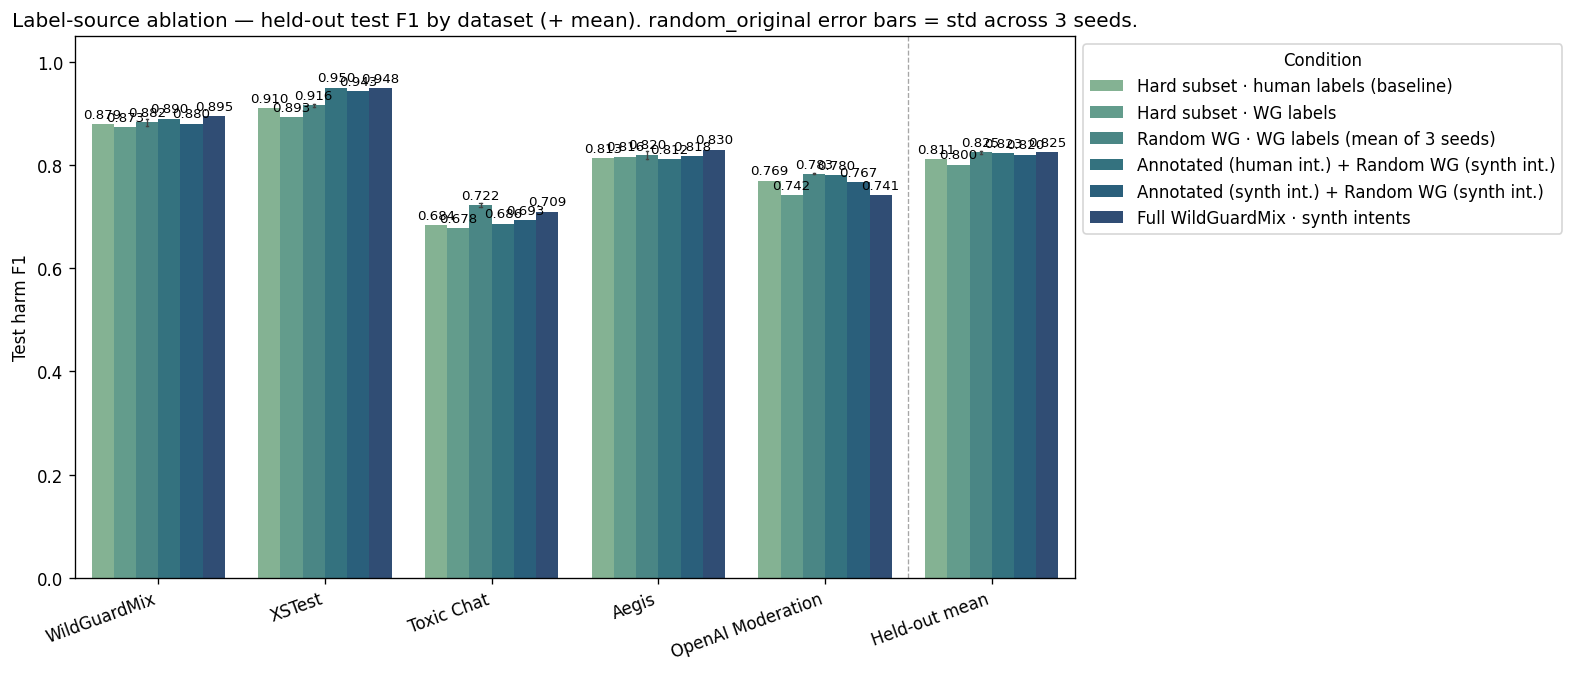

In [6]:
# Per-dataset bar plot — test F1 by group (held-out datasets only).
# annotated-intents is excluded since its val split was used for adapter selection;
# the rightmost group is the mean across all bars shown.
# For random_original, the bar height is the seed-mean and the error bar is
# the std across the 3 seeds. Other groups have only one underlying run, so
# their error bars collapse to zero width.
HELD_OUT_LABEL = "Held-out mean"

# Per-dataset rows (one row per (condition, dataset)). For the held-out
# summary, average each condition over the held-out datasets first so the
# summary error bar reflects seed variability rather than dataset variability.
per_dataset_df = long_df[long_df["dataset_slug"].isin(HELD_OUT_DATASETS)].copy()
summary_df = (
    per_dataset_df.groupby(["condition_slug", "condition", "group_slug", "group"], as_index=False)["f1"]
    .mean()
    .assign(dataset_slug="__held_out_mean__", dataset=HELD_OUT_LABEL, n=0)
)
plot_df = pd.concat([per_dataset_df, summary_df], ignore_index=True)

dataset_order = [DATASETS[d] for d in HELD_OUT_DATASETS] + [HELD_OUT_LABEL]
group_order   = [GROUP_LABELS[g] for g in GROUP_ORDER]
plot_df["dataset"] = pd.Categorical(plot_df["dataset"], categories=dataset_order, ordered=True)
plot_df["group"]   = pd.Categorical(plot_df["group"],   categories=group_order,   ordered=True)

fig, ax = plt.subplots(figsize=(13, 5.5), constrained_layout=True)
sns.barplot(
    data=plot_df,
    x="dataset",
    y="f1",
    hue="group",
    palette="crest",
    ax=ax,
    errorbar="sd",
    capsize=0.08,
    err_kws={"linewidth": 0.8},
)

# Numeric labels above each bar (mean only — std is in the error bar).
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=8, rotation=0)

sep_x = len(HELD_OUT_DATASETS) - 0.5
ax.axvline(sep_x, color="grey", linestyle="--", linewidth=0.8, alpha=0.7)

ax.set_ylabel("Test harm F1")
ax.set_xlabel("")
ax.set_ylim(0, 1.05)
ax.set_title("Label-source ablation — held-out test F1 by dataset (+ mean). random_original error bars = std across 3 seeds.")
ax.legend(title="Condition", bbox_to_anchor=(1.0, 1.0), loc="upper left")
for label in ax.get_xticklabels():
    label.set_rotation(20)
    label.set_ha("right")
plt.show()


## Raw record counts

Sanity check that every condition was evaluated on the same number of records per dataset (mismatch would indicate a partial run).

In [7]:
n_pivot = long_df.pivot(index="dataset_slug", columns="condition_slug", values="n")
n_pivot = n_pivot.reindex(index=list(DATASETS), columns=list(CONDITIONS))
n_pivot.index = [DATASETS[i] for i in n_pivot.index]
n_pivot.columns = [CONDITIONS[c][0] for c in n_pivot.columns]
n_pivot.index.name = "Dataset"
display(n_pivot.fillna(0).astype(int))

,Hard subset · human labels (baseline),Hard subset · WG labels,Random WG · WG labels (seed=42),Random WG · WG labels (seed=43),Random WG · WG labels (seed=44),Annotated (human int.) + Random WG (synth int.),Annotated (synth int.) + Random WG (synth int.),Full WildGuardMix · synth intents
Dataset,,,,,,,,
Annotated Intents,173,173,173,173,173,173,173,173
WildGuardMix,1699,1699,1699,1699,1699,1699,1699,1699
XSTest,450,450,450,450,450,450,450,450
Toxic Chat,5083,5083,5083,5083,5083,5083,5083,5083
Aegis,1964,1964,1964,1964,1964,1964,1964,1964
OpenAI Moderation,1680,1680,1680,1680,1680,1680,1680,1680
